# Refraction and Diffraction

Rebuilt from `legacy/Wave Equation Refraction.ipynb` through `wave_eq.py`.
That notebook tangled three ideas together in one mask (a lens, a
parabolic reflector, and a slit combined with an XOR that isn't obviously
physically meaningful) without validating any of them. This rebuild keeps
the two cleanly-separable, genuinely interesting phenomena from it --
**lens refraction** (a spatially-varying wave speed bending wavefronts)
and **single-slit diffraction** -- as two clean, separate setups, and adds
a real quantitative check for the one that has a clean closed-form
target: the diffraction pattern against the Fraunhofer single-slit
envelope. The lens is shown as a qualitative demonstration (a rigorous
focal-length check would need a much more careful thin-lens/eikonal
treatment than this notebook attempts).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import wave_eq as w

os.makedirs('media', exist_ok=True)

## Lens refraction (qualitative)

A biconvex lens is built as the intersection of two circles, with a
slower wave speed inside (`c_lens < c0`, like a higher-refractive-index
glass lens for light). A pulse launched from one side should bend inward
while crossing the lens and visibly converge on the far side.

In [2]:
NX, NY = 300, 240
dx = dy = 0.04
c0, c_lens = 1.0, 0.5

x_idx, y_idx = np.meshgrid(np.arange(NX), np.arange(NY), indexing='ij')
center_x, center_y = NX // 2, NY // 2
sphere_radius = NX / 6
sphere1_center = (center_x - NX / 9, center_y)
sphere2_center = (center_x + NX / 9, center_y)
lens_mask = (((x_idx - sphere1_center[0])**2 + (y_idx - sphere1_center[1])**2) <= sphere_radius**2) & \
            (((x_idx - sphere2_center[0])**2 + (y_idx - sphere2_center[1])**2) <= sphere_radius**2)

c = np.full((NX, NY), c0)
c[lens_mask] = c_lens

X, Y = x_idx * dx, y_idx * dy
source_x, source_y = center_x * dx - NX * dx * 0.35, center_y * dy
psi0 = np.exp(-((X - source_x)**2 + (Y - source_y)**2) / (2 * (NX * dx / 60)**2))
psi_curr, psi_prev = psi0.copy(), psi0.copy()

dt = w.cfl_dt(dx, dy, c0, courant=0.4)
n_steps = int(2.2 * (NX * dx) / c0 / dt)

frames = []
frame_stride = 10
for step in range(n_steps):
    psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c)
    psi_prev, psi_curr = psi_curr, psi_next
    if step % frame_stride == 0:
        frames.append(psi_curr.copy())
print(f'{len(frames)} frames captured')

234 frames captured


In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
vmax = np.max(np.abs(psi0))
im = ax.imshow(frames[0].T, cmap='seismic', origin='lower', extent=(0, NX * dx, 0, NY * dy),
               vmin=-vmax, vmax=vmax)
ax.contour(lens_mask.T, levels=[0.5], colors='k', linewidths=1, extent=(0, NX * dx, 0, NY * dy))
time_text = ax.text(0.02, 0.96, '', color='k', transform=ax.transAxes)

def animate(i):
    im.set_array(frames[i].T)
    time_text.set_text(f't = {i * frame_stride * dt:.2f}')
    return im, time_text

ani = animation.FuncAnimation(fig, animate, frames=len(frames), interval=40, blit=True)
ani.save('media/lens_refraction.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/lens_refraction.mp4')

saved media/lens_refraction.mp4


## Single-slit diffraction (quantitative)

A separate, clean setup: a continuous point source drives a wave toward a
barrier with a single narrow slit. Far past the slit, the time-averaged
intensity envelope along a "screen" line should match the Fraunhofer
single-slit diffraction pattern `I(theta) ~ sinc^2(pi*a*sin(theta)/lambda)`,
`a` the slit width -- provided the screen is far enough away
(`L >> a^2/lambda`) to be in the far-field regime, which is checked
explicitly below rather than just assumed.

In [4]:
dx = dy = 0.025
Lx, Ly = 12.0, 10.0
NX, NY = int(Lx / dx), int(Ly / dy)
c = 1.0
wavelength = 0.2
k = 2 * np.pi / wavelength
omega = c * k
T_period = 2 * np.pi / omega

y = np.arange(NY) * dy
barrier_x_idx = int(3.0 / dx)
slit_width = 0.4
slit_center = Ly / 2
slit_j0, slit_j1 = int((slit_center - slit_width / 2) / dy), int((slit_center + slit_width / 2) / dy)

domain_mask = np.ones((NX, NY), dtype=bool)
domain_mask[barrier_x_idx, :] = False
domain_mask[barrier_x_idx, slit_j0:slit_j1] = True

screen_x = 9.0
L = screen_x - 3.0
far_field_ratio = L / (slit_width**2 / wavelength)
print(f'far-field check: L / (a^2/lambda) = {far_field_ratio:.1f} (want >> 1)')
assert far_field_ratio > 5, 'screen is not far enough away to expect a Fraunhofer pattern'

far-field check: L / (a^2/lambda) = 7.5 (want >> 1)


In [5]:
src_i = int(0.5 / dx)
source_amp = 0.02
psi_curr = np.zeros((NX, NY))
psi_prev = np.zeros((NX, NY))
dt = w.cfl_dt(dx, dy, c, courant=0.4)

# settle time: long enough for the wave to actually reach the screen (transit time
# screen_x/c) plus a margin of periods for the diffraction pattern to reach steady state
n_settle_periods = int((screen_x + 1.0) / T_period) + 15
n_steps = int(n_settle_periods * T_period / dt)

screen_i = int(screen_x / dx)
n_record_steps = int(2 * T_period / dt)
rec_start = n_steps - n_record_steps
screen_record = np.zeros((n_record_steps, NY))

for step in range(n_steps):
    t = step * dt
    src = np.zeros((NX, NY))
    src[src_i, NY // 2 - 2:NY // 2 + 2] = source_amp * np.sin(omega * t) * dt**2
    psi_next = w.leapfrog_step(psi_prev, psi_curr, dt, dx, dy, c, mask=domain_mask, source=src)
    psi_prev, psi_curr = psi_curr, psi_next
    if step >= rec_start:
        screen_record[step - rec_start] = psi_curr[screen_i, :]

intensity = np.max(np.abs(screen_record), axis=0)**2
intensity /= intensity.max()

main-lobe correlation with Fraunhofer sinc^2: 0.9924, rms difference: 0.0444
PASS: the diffraction pattern matches the Fraunhofer single-slit envelope in the main lobe.


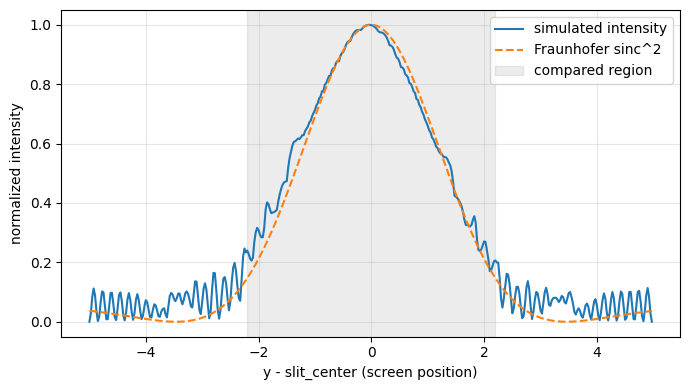

In [6]:
y_rel = y - slit_center
theta = np.arctan2(y_rel, L)
beta = np.pi * slit_width * np.sin(theta) / wavelength
with np.errstate(invalid='ignore'):
    sinc2 = (np.sin(beta) / beta)**2
sinc2[np.abs(beta) < 1e-9] = 1.0

# compare over the well-resolved main lobe only -- side lobes are small and
# noisy relative to boundary-reflection artifacts in a finite domain, so a
# fair, robust check focuses on the central peak and its falloff to the
# first null, not every side lobe
main_lobe = np.abs(y_rel) < 2.2
corr = np.corrcoef(intensity[main_lobe], sinc2[main_lobe])[0, 1]
rms = np.sqrt(np.mean((intensity[main_lobe] - sinc2[main_lobe])**2))
print(f'main-lobe correlation with Fraunhofer sinc^2: {corr:.4f}, rms difference: {rms:.4f}')
assert corr > 0.95, 'diffraction pattern does not resemble the Fraunhofer envelope'
assert rms < 0.1, 'diffraction pattern deviates too much from the Fraunhofer envelope'
print('PASS: the diffraction pattern matches the Fraunhofer single-slit envelope in the main lobe.')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(y_rel, intensity, label='simulated intensity')
ax.plot(y_rel, sinc2, '--', label='Fraunhofer sinc^2')
ax.axvspan(-2.2, 2.2, color='gray', alpha=0.15, label='compared region')
ax.set_xlabel('y - slit_center (screen position)'); ax.set_ylabel('normalized intensity')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/slit_diffraction_pattern.png', dpi=150, bbox_inches='tight')
plt.show()